In [108]:
import pandas as pd
import numpy as np
import scipy.stats as st
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
import cleaning as cl
import create_db as crdb
import analysis as anls

In [109]:
df_1 = pd.read_csv('raw_data/df_final_web_data_pt_1.txt')
df_2 = pd.read_csv('raw_data/df_final_web_data_pt_2.txt')
df_demo = pd.read_csv('raw_data/df_final_demo.txt')
df_clients = pd.read_csv('raw_data/df_final_experiment_clients.txt')

In [110]:
display(df_1)
display(df_2)
display(df_demo)
display(df_clients)

,client_id,visitor_id,visit_id,process_step,date_time
0,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:27:07
1,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:26:51
2,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:19:22
3,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:19:13
4,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:18:04
...,...,...,...,...,...
343136,2443347,465784886_73090545671,136329900_10529659391_316129,confirm,2017-03-31 15:15:46
343137,2443347,465784886_73090545671,136329900_10529659391_316129,step_3,2017-03-31 15:14:53
343138,2443347,465784886_73090545671,136329900_10529659391_316129,step_2,2017-03-31 15:12:08
343139,2443347,465784886_73090545671,136329900_10529659391_316129,step_1,2017-03-31 15:11:37


,client_id,visitor_id,visit_id,process_step,date_time
0,763412,601952081_10457207388,397475557_40440946728_419634,confirm,2017-06-06 08:56:00
1,6019349,442094451_91531546617,154620534_35331068705_522317,confirm,2017-06-01 11:59:27
2,6019349,442094451_91531546617,154620534_35331068705_522317,step_3,2017-06-01 11:58:48
3,6019349,442094451_91531546617,154620534_35331068705_522317,step_2,2017-06-01 11:58:08
4,6019349,442094451_91531546617,154620534_35331068705_522317,step_1,2017-06-01 11:57:58
...,...,...,...,...,...
412259,9668240,388766751_9038881013,922267647_3096648104_968866,start,2017-05-24 18:46:10
412260,9668240,388766751_9038881013,922267647_3096648104_968866,start,2017-05-24 18:45:29
412261,9668240,388766751_9038881013,922267647_3096648104_968866,step_1,2017-05-24 18:44:51
412262,9668240,388766751_9038881013,922267647_3096648104_968866,start,2017-05-24 18:44:34


,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth
0,836976,6.0,73.0,60.5,U,2.0,45105.30,6.0,9.0
1,2304905,7.0,94.0,58.0,U,2.0,110860.30,6.0,9.0
2,1439522,5.0,64.0,32.0,U,2.0,52467.79,6.0,9.0
3,1562045,16.0,198.0,49.0,M,2.0,67454.65,3.0,6.0
4,5126305,12.0,145.0,33.0,F,2.0,103671.75,0.0,3.0
...,...,...,...,...,...,...,...,...,...
70604,7993686,4.0,56.0,38.5,U,3.0,1411062.68,5.0,5.0
70605,8981690,12.0,148.0,31.0,M,2.0,101867.07,6.0,6.0
70606,333913,16.0,198.0,61.5,F,2.0,40745.00,3.0,3.0
70607,1573142,21.0,255.0,68.0,M,3.0,475114.69,4.0,4.0


,client_id,Variation
0,9988021,Test
1,8320017,Test
2,4033851,Control
3,1982004,Test
4,9294070,Control
...,...,...
70604,2443347,NaN
70605,8788427,NaN
70606,266828,NaN
70607,1266421,NaN


In [111]:
# merge web_data_pt
web_data_pt_df = pd.concat([df_1, df_2],axis=0)
web_data_pt_df
# check for duplicates
web_data_pt_df.duplicated(subset=['client_id', 'visitor_id', 'visit_id', 'process_step', 'date_time']).sum()

np.int64(10764)

In [112]:
# Find and inspect the duplicates in merged web_data_pt
mask = web_data_pt_df.duplicated(
    subset=['client_id','visitor_id','visit_id','process_step','date_time'],
    keep=False
)
web_data_pt_df[mask].sort_values(
    ['client_id','visitor_id','visit_id','process_step','date_time']
).tail(10)

,client_id,visitor_id,visit_id,process_step,date_time
295096,9995203,550384864_76045959210,823630151_22344597498_646045,start,2017-06-11 12:23:43
295097,9995203,550384864_76045959210,823630151_22344597498_646045,start,2017-06-11 12:23:43
85991,9996877,83108209_22162646095,713500557_31297619237_860300,start,2017-05-03 18:08:32
85992,9996877,83108209_22162646095,713500557_31297619237_860300,start,2017-05-03 18:08:32
256561,9997801,500453195_9636586711,829652786_55390211114_665695,start,2017-04-28 10:59:18
256562,9997801,500453195_9636586711,829652786_55390211114_665695,start,2017-04-28 10:59:18
119532,9998346,292425655_16607136645,189177304_69869411700_783154,step_3,2017-03-29 15:37:28
119534,9998346,292425655_16607136645,189177304_69869411700_783154,step_3,2017-03-29 15:37:28
63673,9998447,747535871_38029188908,309540451_47388672022_606106,start,2017-06-03 19:17:15
63674,9998447,747535871_38029188908,309540451_47388672022_606106,start,2017-06-03 19:17:15


In [113]:
deduplicated_web_data_df = cl.clean_web_duplicates(web_data_df=web_data_pt_df)

In [114]:
mask = deduplicated_web_data_df.duplicated(
    subset=['client_id', 'visitor_id', 'visit_id','process_step'],
    keep=False)
deduplicated_web_data_df[mask].sort_values(
    ['client_id','visitor_id','visit_id','process_step','date_time']
).head(10)

,client_id,visitor_id,visit_id,process_step,date_time
285315,336,64757908_3400128256,649044751_80905125055_554468,start,2017-06-01 07:26:55
285190,336,64757908_3400128256,649044751_80905125055_554468,start,2017-06-01 07:42:43
245500,722,919259913_64837298108,984487154_55831795985_521110,start,2017-04-19 14:50:10
245496,722,919259913_64837298108,984487154_55831795985_521110,start,2017-04-19 14:56:16
245499,722,919259913_64837298108,984487154_55831795985_521110,step_1,2017-04-19 14:50:20
245497,722,919259913_64837298108,984487154_55831795985_521110,step_1,2017-04-19 14:51:12
245495,722,919259913_64837298108,984487154_55831795985_521110,step_1,2017-04-19 14:56:18
245498,722,919259913_64837298108,984487154_55831795985_521110,step_2,2017-04-19 14:50:56
245494,722,919259913_64837298108,984487154_55831795985_521110,step_2,2017-04-19 14:56:37
100903,786,439747392_30293505155,640294664_79662229470_499394,start,2017-06-01 11:00:22


In [115]:
# deduplicate the rows with the same client_id, visitor_id, visit_id, process_step, but different times.
# That means the same user made a pause and retry later
session_deduplicated_web_data_df = cl.clean_web_session_duplicates(deduplicated_web_data_df)
session_deduplicated_web_data_df

,client_id,visitor_id,visit_id,process_step,date_time
4,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:18:04
5,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:17:15
6,9988021,580560515_7732621733,781255054_21935453173_531117,step_1,2017-04-17 15:17:01
7,9988021,580560515_7732621733,781255054_21935453173_531117,start,2017-04-17 15:16:22
8,8320017,39393514_33118319366,960651974_70596002104_312201,confirm,2017-04-05 13:10:05
...,...,...,...,...,...
412254,9668240,388766751_9038881013,922267647_3096648104_968866,step_3,2017-05-24 18:51:04
412257,9668240,388766751_9038881013,922267647_3096648104_968866,step_2,2017-05-24 18:48:11
412261,9668240,388766751_9038881013,922267647_3096648104_968866,step_1,2017-05-24 18:44:51
412262,9668240,388766751_9038881013,922267647_3096648104_968866,start,2017-05-24 18:44:34


In [116]:
# check for null values
session_deduplicated_web_data_df.isnull().sum()

client_id       0
visitor_id      0
visit_id        0
process_step    0
date_time       0
dtype: int64

In [117]:
session_deduplicated_web_data_df.nunique()

client_id       120157
visitor_id      130236
visit_id        158095
process_step         5
date_time       484870
dtype: int64

In [118]:
session_deduplicated_web_data_df['process_step'].value_counts()

process_step
start      145835
step_1     120122
step_2     105145
step_3      95874
confirm     90638
Name: count, dtype: int64

In [119]:
# drop clients not participating in the experiment (Nan values in variation column)
# normalize the df column names

client_df = cl.normalize_column_names(df=df_clients)
participating_client_df = cl.drop_not_participating_clients(clients_df=client_df)
participating_client_df


,client_id,variation
0,9988021,Test
1,8320017,Test
2,4033851,Control
3,1982004,Test
4,9294070,Control
...,...,...
50495,393005,Control
50496,2908510,Control
50497,7230446,Test
50498,5230357,Test


In [120]:
#check for duplicated client_id
participating_client_df.duplicated(subset=['client_id']).sum()

np.int64(0)

In [121]:
# check for duplicated
# normalize df
demo_df = cl.normalize_column_names(df_demo)
demo_df.duplicated(subset=['client_id']).sum()

np.int64(0)

In [122]:
# check for null values
demo_df[demo_df.isnull().any(axis=1)]

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth
4164,7402828,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8316,355337,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8677,8412164,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9583,4666211,8.0,106.0,NaN,F,2.0,42550.55,4.0,7.0
13444,2222915,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18066,4876926,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25961,5277910,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
28432,7616759,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
35323,8191345,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
43518,1227228,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [123]:
# Count nulls in each row, then keep rows with ≤1 null
clean_demo_df = cl.drop_null_clients(demo_df)
clean_demo_df[clean_demo_df.isnull().any(axis=1)]

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth
9583,4666211,8.0,106.0,NaN,F,2.0,42550.55,4.0,7.0


In [124]:
clean_demo_df['clnt_tenure_yr'].value_counts().sort_values()

clnt_tenure_yr
41.0       1
54.0       1
62.0       1
45.0       1
52.0       2
44.0       3
49.0       4
46.0       5
51.0       5
47.0       6
43.0       6
42.0       6
50.0       8
40.0       9
39.0       9
55.0       9
48.0      16
38.0      33
37.0      35
36.0      36
2.0       81
35.0     102
31.0     166
34.0     175
32.0     191
33.0     206
30.0     303
29.0     309
3.0      449
25.0     484
28.0     507
27.0     632
26.0     660
24.0     846
19.0    1153
18.0    1206
23.0    1279
17.0    1373
22.0    1492
20.0    1580
21.0    2257
16.0    2714
10.0    2775
11.0    2920
9.0     3357
13.0    3607
12.0    3631
14.0    3646
8.0     4045
15.0    4564
4.0     4687
7.0     4955
5.0     6955
6.0     7092
Name: count, dtype: int64

In [125]:
# X: Non binary / Other / Third gender, U: Unknown
clean_demo_df['gendr'].value_counts()

gendr
U    24122
M    23724
F    22746
X        3
Name: count, dtype: int64

In [126]:
# check demo_df types
clean_demo_df.dtypes

client_id             int64
clnt_tenure_yr      float64
clnt_tenure_mnth    float64
clnt_age            float64
gendr                object
num_accts           float64
bal                 float64
calls_6_mnth        float64
logons_6_mnth       float64
dtype: object

In [127]:
# clean age type to int
clean_demo_df = cl.convert_client_age_to_int(clean_demo_df)
clean_demo_df.dtypes

client_id             int64
clnt_tenure_yr      float64
clnt_tenure_mnth    float64
clnt_age              Int64
gendr                object
num_accts           float64
bal                 float64
calls_6_mnth        float64
logons_6_mnth       float64
dtype: object

In [128]:
clean_demo_df = cl.rename_demo_columns(clean_demo_df)
clean_demo_df

,client_id,tenure_yr,tenure_months,age,gender,num_accounts,balance,calls_6_months,logins_6_months
0,836976,6.0,73.0,60,U,2.0,45105.30,6.0,9.0
1,2304905,7.0,94.0,58,U,2.0,110860.30,6.0,9.0
2,1439522,5.0,64.0,32,U,2.0,52467.79,6.0,9.0
3,1562045,16.0,198.0,49,M,2.0,67454.65,3.0,6.0
4,5126305,12.0,145.0,33,F,2.0,103671.75,0.0,3.0
...,...,...,...,...,...,...,...,...,...
70604,7993686,4.0,56.0,38,U,3.0,1411062.68,5.0,5.0
70605,8981690,12.0,148.0,31,M,2.0,101867.07,6.0,6.0
70606,333913,16.0,198.0,62,F,2.0,40745.00,3.0,3.0
70607,1573142,21.0,255.0,68,M,3.0,475114.69,4.0,4.0


In [129]:
session_deduplicated_web_data_df['date_time'].dtypes

dtype('O')

In [130]:
# Cast date_time as 'datetime64[s]'
cl.convert_datetime_to_date_time(session_deduplicated_web_data_df)

c:\Users\orian\Desktop\IH_projects\vanguard-ab-test\cleaning.py:46: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  web_data_df['date_time'] = web_data_df['date_time'].astype('datetime64[s]')


,client_id,visitor_id,visit_id,process_step,date_time
4,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:18:04
5,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:17:15
6,9988021,580560515_7732621733,781255054_21935453173_531117,step_1,2017-04-17 15:17:01
7,9988021,580560515_7732621733,781255054_21935453173_531117,start,2017-04-17 15:16:22
8,8320017,39393514_33118319366,960651974_70596002104_312201,confirm,2017-04-05 13:10:05
...,...,...,...,...,...
412254,9668240,388766751_9038881013,922267647_3096648104_968866,step_3,2017-05-24 18:51:04
412257,9668240,388766751_9038881013,922267647_3096648104_968866,step_2,2017-05-24 18:48:11
412261,9668240,388766751_9038881013,922267647_3096648104_968866,step_1,2017-05-24 18:44:51
412262,9668240,388766751_9038881013,922267647_3096648104_968866,start,2017-05-24 18:44:34


In [131]:
## Applying the function to get the time difference between steps per visit_id.
anls.time_diff(session_deduplicated_web_data_df)

## Applying the function to get the step difference between steps per visit_id to identify errors as negative values.
anls.step_diff(session_deduplicated_web_data_df)

c:\Users\orian\Desktop\IH_projects\vanguard-ab-test\analysis.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe.sort_values(by=['visit_id', 'date_time'], ignore_index=True, inplace=True)
c:\Users\orian\Desktop\IH_projects\vanguard-ab-test\analysis.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe['time_diff'] = dataframe.groupby('visit_id')['date_time'].diff().dt.total_seconds()
c:\Users\orian\Desktop\IH_projects\vanguard-ab-test\analysis.py:28: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained 

,client_id,visitor_id,visit_id,process_step,date_time,time_diff,step_diff,step_cum_sum
0,3561384,451664975_1722933822,100012776_37918976071_457913,4,2017-04-26 13:22:17,NaN,NaN,NaN
1,9056452,306992881_89423906595,1000165_4190026492_760066,0,2017-06-04 01:07:29,NaN,NaN,NaN
2,9056452,306992881_89423906595,1000165_4190026492_760066,1,2017-06-04 01:07:32,3.0,1.0,1.0
3,9056452,306992881_89423906595,1000165_4190026492_760066,2,2017-06-04 01:07:56,24.0,1.0,2.0
4,9056452,306992881_89423906595,1000165_4190026492_760066,3,2017-06-04 01:09:13,77.0,1.0,3.0
...,...,...,...,...,...,...,...,...
557609,7149380,483112224_46340533900,999992932_41666455053_671149,0,2017-06-06 15:46:03,NaN,NaN,NaN
557610,7149380,483112224_46340533900,999992932_41666455053_671149,1,2017-06-06 15:46:24,21.0,1.0,1.0
557611,7149380,483112224_46340533900,999992932_41666455053_671149,2,2017-06-06 15:47:32,68.0,1.0,2.0
557612,7149380,483112224_46340533900,999992932_41666455053_671149,3,2017-06-06 16:01:46,854.0,1.0,3.0


### This creates the DB 'vanguard' and populates the tables
The cell stays commented out to prevent overwritting the DB and create conflicts

In [132]:
#crdb.save_dataframes_to_db(participating_client_df, clean_demo_df, session_deduplicated_web_data_df)

## Completion Rate

In [134]:
# The function anls.query_db runs queries on the 'vanguard' database and returns outputs as dataframes.
## This query gets the rows for clients that have been assigened control or test group, groups them and counts how many
## reached completion (i.e. went through steps 0, 1, 2, 3 and 4)
query = """
-- Completion Rate:
SELECT  p.variation,
  		s.step_cum_sum,
		count(*) AS count
FROM `session` s
JOIN participants p
	ON p.client_id = s.client_id
GROUP BY p. variation, s.step_cum_sum
""" 
total_number = anls.query_db(query)
total_number

,variation,step_cum_sum,count
0,Test,NaN,36985
1,Test,1.0,28549
2,Test,2.0,24361
3,Test,3.0,21682
4,Test,4.0,17854
5,Control,NaN,32015
6,Control,1.0,23775
7,Control,2.0,20056
8,Control,3.0,17948
9,Control,-3.0,21


In [ ]:
# Total count of test and control trials
total_number.groupby('variation').sum('count')['count']

variation
Control    109172
Test       130159
Name: count, dtype: int64

In [135]:
# Count of test and control successes (completed steps 0 to 4)
total_number[total_number['step_cum_sum'] == 4.0].set_index('variation')['count']

variation
Test       17854
Control    14868
Name: count, dtype: int64

In [136]:
# Completion rate for test and control
total_number[total_number['step_cum_sum'] == 4].set_index('variation')['count'] / total_number.groupby('variation').sum('count')['count']

variation
Control    0.136189
Test       0.137171
Name: count, dtype: float64

In [137]:
# Creating a new boolean column to enable creation of a crosstab and run chi2 test
total_number['step_group'] = total_number['step_cum_sum'].apply(lambda x: 'completed' if x == 4.0 else 'non_completed')

In [138]:
# Create the crosstab
crosstab = total_number.groupby(['variation', 'step_group'])['count'].sum().unstack(fill_value=0)
crosstab

step_group,completed,non_completed
variation,,
Control,14868,94304
Test,17854,112305


In [139]:
# Run the chi2 test
from scipy.stats import chi2_contingency

p_value_chi2 = chi2_contingency(crosstab)[1]
print(f'P value: {round(p_value_chi2, 3)}')   # Conclusion: no sufficient evidence to conclude relationship between Test and Control

P value: 0.49


In [140]:
## Two-proportion z-test to assess completion rate

# H0: completion_rate_test = completion_rate_control
# H1: completion_rate_test != completion_rate_control

# significance level = 0.05

import statsmodels.api as sm

p_val_ztest = sm.stats.proportions_ztest(np.array([14868, 17854]),
                                         np.array([109172, 130159]),
                                         alternative='two-sided'
                                         )[1]
print(f'P value: {round(p_val_ztest, 3)}')   # Conclusion: We fail to reject H0, the completion rate is the same for Test and Control.

P value: 0.486


In [141]:
## One-sided Two-proportion z-test to assess Completion Rate with a Cost-Effectiveness Threshold

# H0: completion_rate_test <= completion_rate_control + 0.05
# H1: completion_rate_test > completion_rate_control + 0.05

# significance level = 0.05

p_value_cost_effect = sm.stats.proportions_ztest(np.array([17854, 14868]),
                                                 np.array([130159, 109172]), 
                                                 value=0.05, 
                                                 alternative='larger'
                                                 )[1]
print(f'P value: {round(p_value_cost_effect, 3)}')   # Conclusion: We fail to reject H0, the completion rate in the test is not bigger than 5% compared to control.

P value: 1.0


## Average time per step

In [142]:
# The function anls.query_db runs queries on the 'vanguard' database and returns outputs as dataframes.
## This query gets the rows for clients that have been assigned control or test group and the time spent on each step
## if the row is not an ERROR (step_diff = 1, i.e. went from 0 to 1, or 1 to 2, etc.)
## process_step = 1 refers to the time spent from step 0 to 1; process_step = 2 refers from step 1 to 2, etc.
query = """
-- Avg time/step:
SELECT  p.variation,
		s.process_step,
        s.time_diff
FROM `session` s
JOIN participants p
	ON p.client_id = s.client_id
WHERE s.step_diff =1
"""
time_step = anls.query_db(query)
time_step

,variation,process_step,time_diff
0,Test,1,16.0
1,Test,2,9.0
2,Test,3,160.0
3,Test,4,57.0
4,Test,1,22.0
...,...,...,...
168677,Control,2,38.0
168678,Control,3,101.0
168679,Control,4,843.0
168680,Test,1,11.0


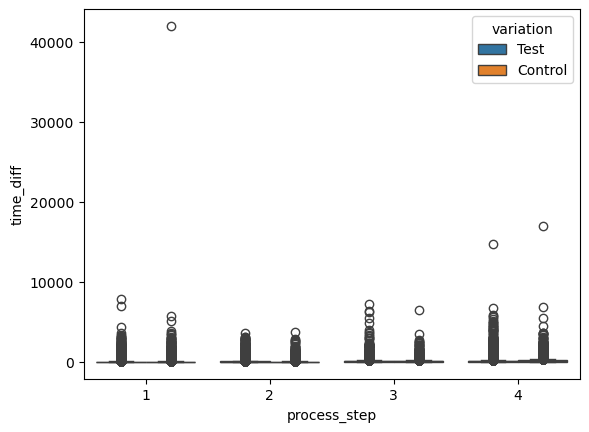

In [143]:
# Plotting a boxplot to glimpse at the distributions and possible outliers.
sns.boxplot(data = time_step, x= 'process_step', y= 'time_diff', hue= 'variation')
plt.show()

# Clearly, one has to address the large number of outliers

In [144]:
time_step_filtered = cl.drop_outliers(time_step, time_step['time_diff'])

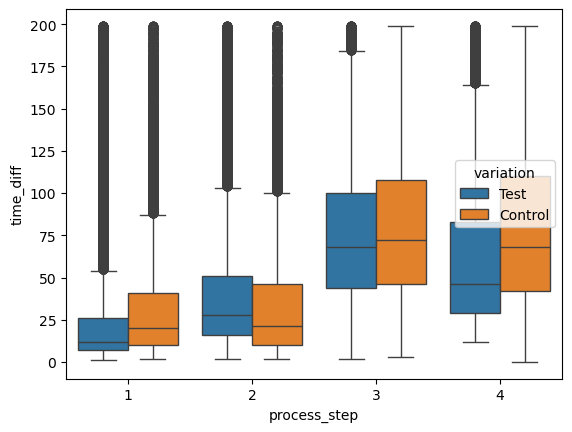

In [145]:
# Plotting a boxplot to glimpse at the distributions after removing outliers.
sns.boxplot(data = time_step_filtered, x= 'process_step', y= 'time_diff', hue= 'variation', whis=1.5)
plt.show()

 #It's better, although there are some steps that are still very skewed.

In [146]:
# Calculating the average time per step and variation of experiment.
avg_time_step = time_step_filtered.groupby(['variation', 'process_step']).mean('time_diff')

In [223]:
avg_time_step

time_diff
variation process_step           
Control   1             31.947083
          2             34.057287
          3             80.500372
          4             79.737815
Test      1             26.549728
          2             40.589934
          3             76.272387
          4             61.661802

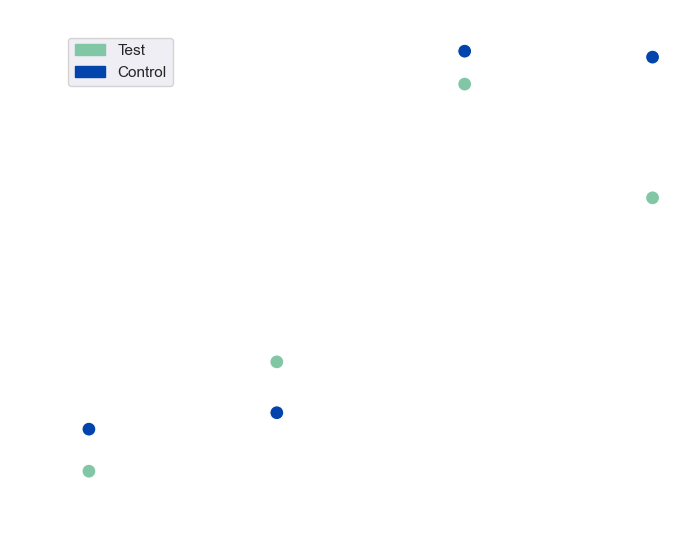

In [199]:
# Custom palette
custom_palette = {
    'Test': '#82c7a5',     
    'Control': '#0145ac'
}

# Create the plot
plt.figure(figsize=(8, 6), facecolor='none')  # Transparent figure
sns.set_theme(style="dark")  # Use a dark style for better white axis contrast

# Plot the scatterplot
sns.scatterplot(
    data=avg_time_step,
    x='process_step',
    y='time_diff',
    hue='variation',
    palette=custom_palette,
    s=100
)

# Set axis tick positions on x-axis
plt.xticks([1, 2, 3, 4])

# Make background transparent
ax = plt.gca()
ax.set_facecolor('none')  # Transparent axes background
ax.xaxis.label.set_color('white')
ax.yaxis.label.set_color('white')
ax.tick_params(colors='white')

# Set axis spine colors to white
for spine in ax.spines.values():
    spine.set_color('white')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


# Set axis label and tick color to white
ax.xaxis.label.set_color('white')
ax.yaxis.label.set_color('white')
ax.tick_params(colors='white')

# Custom legend handles
legend_handles = [
    Patch(color=color, label=label)
    for label, color in custom_palette.items()
]

plt.title('Average time/step', color='white')
plt.xlabel('Step')
plt.ylabel('Time (s)')
plt.legend(handles=legend_handles, title=None)

# Show plot
plt.show()



In [ ]:
## T test to assess equality of average times from step 0 to step 1 between Test and Control 

# H0: avg_time_test >= avg_time_control
# H1: avg_time_test < avg_time_control

alpha = 0.05
if st.ttest_ind(
                time_step_filtered[(time_step_filtered['variation']=='Test') & (time_step_filtered['process_step']==1)]['time_diff'],
                time_step_filtered[(time_step_filtered['variation']=='Control') & (time_step_filtered['process_step']==1)]['time_diff'],
                alternative = "less"
                )[1] > alpha:
    print("We are not able to reject the null hypothesis")
else:
    print("We reject the null hypotesis")

We reject the null hypotesis


In [ ]:
## T test to assess equality of average times from step 1 to step 2 between Test and Control 

# H0: avg_time_test <= avg_time_control
# H1: avg_time_test > avg_time_control

alpha = 0.05
if st.ttest_ind(
                time_step_filtered[(time_step_filtered['variation']=='Test') & (time_step_filtered['process_step']==2)]['time_diff'],
                time_step_filtered[(time_step_filtered['variation']=='Control') & (time_step_filtered['process_step']==2)]['time_diff'],
                alternative = "greater"
                )[1] > alpha:
    print("We are not able to reject the null hypothesis")
else:
    print("We reject the null hypotesis")

We reject the null hypotesis


In [ ]:
## T test to assess equality of average times from step 2 to step 3 between Test and Control 

# H0: avg_time_test >= avg_time_control
# H1: avg_time_test < avg_time_control

alpha = 0.05
if st.ttest_ind(
                time_step_filtered[(time_step_filtered['variation']=='Test') & (time_step_filtered['process_step']==3)]['time_diff'],
                time_step_filtered[(time_step_filtered['variation']=='Control') & (time_step_filtered['process_step']==3)]['time_diff'],
                alternative = "less"
                )[1] > alpha:
    print("We are not able to reject the null hypothesis")
else:
    print("We reject the null hypotesis")

We reject the null hypotesis


In [ ]:
## T test to assess equality of average times from step 3 to step 4 between Test and Control 

# H0: avg_time_test >= avg_time_control
# H1: avg_time_test < avg_time_control

alpha = 0.05
if st.ttest_ind(
                time_step_filtered[(time_step_filtered['variation']=='Test') & (time_step_filtered['process_step']==4)]['time_diff'],
                time_step_filtered[(time_step_filtered['variation']=='Control') & (time_step_filtered['process_step']==4)]['time_diff'],
                alternative = "less"
                )[1] > alpha:
    print("We are not able to reject the null hypothesis")
else:
    print("We reject the null hypotesis")

We reject the null hypotesis


## Error rates

In [151]:
# The function anls.query_db runs queries on the 'vanguard' database and returns outputs as dataframes.
## This query gets the rows for clients that have been assigned control or test group; and have step_diff < 0, meaning
## they returned to a previous step.
query = """
-- Error Rates per step:
SELECT  p.variation,
  		s.process_step,
        s.step_diff,
		count(*) AS count
FROM `session` AS s
JOIN participants AS p
	ON p.client_id = s.client_id
WHERE (s.step_diff < 0) AND (s.step_diff != -4)
GROUP BY p.variation,
  		s.process_step,
        s.step_diff
ORDER BY p.variation,
		 s.process_step;
""" 
errors = anls.query_db(query)
errors

,variation,process_step,step_diff,count
0,Control,0,-3.0,64
1,Control,0,-2.0,37
2,Control,0,-1.0,49
3,Control,1,-3.0,12
4,Control,1,-2.0,25
5,Control,1,-1.0,26
6,Control,2,-1.0,39
7,Control,3,-1.0,1
8,Test,0,-3.0,125
9,Test,0,-2.0,73


In [152]:
# Creates a new column to retrieve the step where the error was committed (i.e. the previous row in the original dataframe)
errors['error_on_step'] = errors['process_step'] - errors['step_diff']
errors

,variation,process_step,step_diff,count,error_on_step
0,Control,0,-3.0,64,3.0
1,Control,0,-2.0,37,2.0
2,Control,0,-1.0,49,1.0
3,Control,1,-3.0,12,4.0
4,Control,1,-2.0,25,3.0
5,Control,1,-1.0,26,2.0
6,Control,2,-1.0,39,3.0
7,Control,3,-1.0,1,4.0
8,Test,0,-3.0,125,3.0
9,Test,0,-2.0,73,2.0


In [153]:
# Grouping to count errors per step and variation
errors_step = errors.drop(columns=['process_step', 'step_diff']).groupby(['variation', 'error_on_step']).sum()
errors_step

count
variation error_on_step       
Control   1.0               49
          2.0               63
          3.0              128
          4.0               13
Test      1.0              110
          2.0              133
          3.0              197
          4.0               11

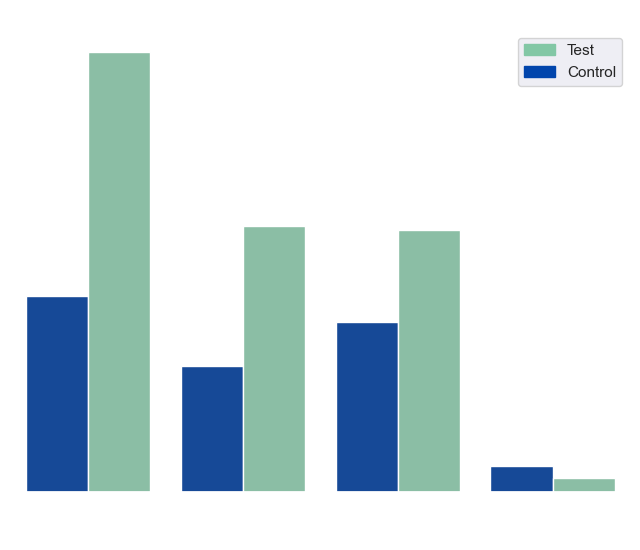

In [222]:
# Custom palette
custom_palette = {
    'Test': '#82c7a5',     
    'Control': '#0145ac'
}
# Create the plot
plt.figure(figsize=(8, 6), facecolor='none')  # Transparent figure
sns.set_theme(style="dark")  # Use a dark style for better white axis contrast

sns.barplot(data=errors, x='error_on_step', y='count', hue='variation', errorbar=None, palette=custom_palette)
# Make background transparent
ax = plt.gca()
ax.set_facecolor('none')  # Transparent axes background
ax.xaxis.label.set_color('white')
ax.yaxis.label.set_color('white')
ax.tick_params(colors='white')

# Set axis spine colors to white
for spine in ax.spines.values():
    spine.set_color('white')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.yaxis.set_visible(False)


# Set axis label and tick color to white
ax.xaxis.label.set_color('white')
ax.yaxis.label.set_color('white')
ax.tick_params(colors='white')
# Custom legend handles
legend_handles = [
    Patch(color=color, label=label)
    for label, color in custom_palette.items()
]
# Add text labels on top of each bar
for bar in ax.patches:
    height = bar.get_height()
    if height > 0:  # Skip if bar height is 0
        plt.text(
            bar.get_x() + bar.get_width() / 2,  # x position: center of bar
            height,                             # y position: top of bar
            f'{int(height)}',                   # display value as integer
            ha='center', va='bottom',
            color='white', fontsize=10
        )
plt.title('Error count', color='white')
plt.xlabel('Step')
plt.ylabel('')
plt.legend(handles=legend_handles, title=None)

# Show plot
plt.show()

In [154]:
## This query gets counts per step per variation to later calculate error rates.

query = """
-- Error Rates per step:
SELECT  p.variation,
  		s.process_step,
		count(*) AS count
FROM `session` AS s
JOIN participants AS p
	ON p.client_id = s.client_id
WHERE process_step !=0
GROUP BY p.variation,
  		s.process_step
ORDER BY p.variation,
		 s.process_step;
""" 
steps = anls.query_db(query)
steps

,variation,process_step,count
0,Control,1,23595
1,Control,2,20182
2,Control,3,18345
3,Control,4,16088
4,Test,1,28345
5,Test,2,24562
6,Test,3,22242
7,Test,4,21791


In [155]:
# This is an intermediate step to get a table in the right format to divide by errors_step
step_count = steps.groupby(['variation', 'process_step']).sum()
step_count

count
variation process_step       
Control   1             23595
          2             20182
          3             18345
          4             16088
Test      1             28345
          2             24562
          3             22242
          4             21791

In [156]:
# This gets the error rate on every step
error_rates = errors_step/step_count
error_rates

count
variation error_on_step          
Control   1.0            0.002077
          2.0            0.003122
          3.0            0.006977
          4.0            0.000808
Test      1.0            0.003881
          2.0            0.005415
          3.0            0.008857
          4.0            0.000505

In [220]:
error_rates[error_rates['variation']=='Test'].iloc[0]

KeyError: 'variation'

In [157]:
## Two-proportion z-test to assess error rate on step 1

# H0: error_rate_test = error_rate_control
# H1: error_rate_test != error_rate_control

# significance level = 0.05

import statsmodels.api as sm

p_val_ztest = sm.stats.proportions_ztest(np.array([110, 49]),
                                         np.array([28345, 23595]),
                                         alternative='two-sided'
                                         )[1]
print(f'P value: {round(p_val_ztest, 5)}')   # Conclusion: We reject H0, the error rate is different for Test and Control.

P value: 0.00021


In [158]:
## Two-proportion z-test to assess error rate on step 2

# H0: error_rate_test = error_rate_control
# H1: error_rate_test != error_rate_control

# significance level = 0.05

import statsmodels.api as sm

p_val_ztest = sm.stats.proportions_ztest(np.array([133, 63]),
                                         np.array([24562, 20182]),
                                         alternative='two-sided'
                                         )[1]
print(f'P value: {round(p_val_ztest, 5)}')   # Conclusion: We reject H0, the error rate is different for Test and Control.

P value: 0.00026


In [159]:
## Two-proportion z-test to assess error rate on step 3

# H0: error_rate_test = error_rate_control
# H1: error_rate_test != error_rate_control

# significance level = 0.05

import statsmodels.api as sm

p_val_ztest = sm.stats.proportions_ztest(np.array([197, 128]),
                                         np.array([22242, 18345]),
                                         alternative='two-sided'
                                         )[1]
print(f'P value: {round(p_val_ztest, 5)}')   # Conclusion: We reject H0, the error rate is different for Test and Control.

P value: 0.03446


In [160]:
## Two-proportion z-test to assess error rate on step 4

# H0: error_rate_test = error_rate_control
# H1: error_rate_test != error_rate_control

# significance level = 0.05

import statsmodels.api as sm

p_val_ztest = sm.stats.proportions_ztest(np.array([11, 13]),
                                         np.array([21791, 16088]),
                                         alternative='two-sided'
                                         )[1]
print(f'P value: {round(p_val_ztest, 5)}')   # Conclusion: We fail to reject H0, the error rate is NOT different for Test and Control.

P value: 0.24629


## Average age 

In [161]:
# The function anls.query_db runs queries on the 'vanguard' database and returns outputs as dataframes.
## This query gets the age per variation of participating clients.
query = """
-- Age per variation:
SELECT 	c.age,
		p.variation
FROM `clients` AS c
JOIN participants AS p
	ON p.client_id = c.client_id;
""" 
age = anls.query_db(query)
age

,age,variation
0,30.0,Test
1,58.0,Test
2,51.0,Test
3,36.0,Control
4,48.0,Control
...,...,...
50483,30.0,Test
50484,28.0,Test
50485,35.0,Test
50486,31.0,Test


In [162]:
# Average age of participating clients per variation group
round(age.groupby('variation').mean('age'), 2)

,age
variation,
Control,47.50
Test,47.17


In [163]:
## T test to assess equality of average age between Test and Control 

# H0: avg_age_test = avg_age_control
# H1: avg_age_test != avg_age_control

alpha = 0.05
if st.ttest_ind(
                age[age['variation']=='Test']['age'],
                age[age['variation']=='Control']['age'],
                nan_policy='omit',   # There is a null value in the age Series
                alternative = "two-sided"
                )[1] > alpha:
    print("We are not able to reject the null hypothesis")
else:
    print("We reject the null hypotesis")  #i.e. The average age is statistically different

We reject the null hypotesis


## Tableau

In [164]:
# This dataframe is exported to create visualisation in tableau
query = """
-- Demographics:
SELECT  c.*,
		p.variation
FROM `clients` AS c
LEFT JOIN participants AS p
	ON p.client_id = c.client_id;
""" 
demographics = anls.query_db(query)
demographics.to_excel("demographics.xlsx")

In [166]:
demographics.head(2)

,client_id,tenure_yr,tenure_months,age,gender,num_accounts,balance,calls_6_months,logins_6_months,variation
0,169,21.0,262.0,48.0,M,2.0,501570.72,4.0,4.0,None
1,555,3.0,46.0,30.0,U,2.0,25454.66,2.0,6.0,Test


In [168]:
time_step_filtered.to_excel("time_step.xlsx")

In [169]:
errors.to_excel("errors.xlsx")

In [170]:
steps.to_excel("steps.xlsx")

AttributeError: 'str' object has no attribute 'get_label'

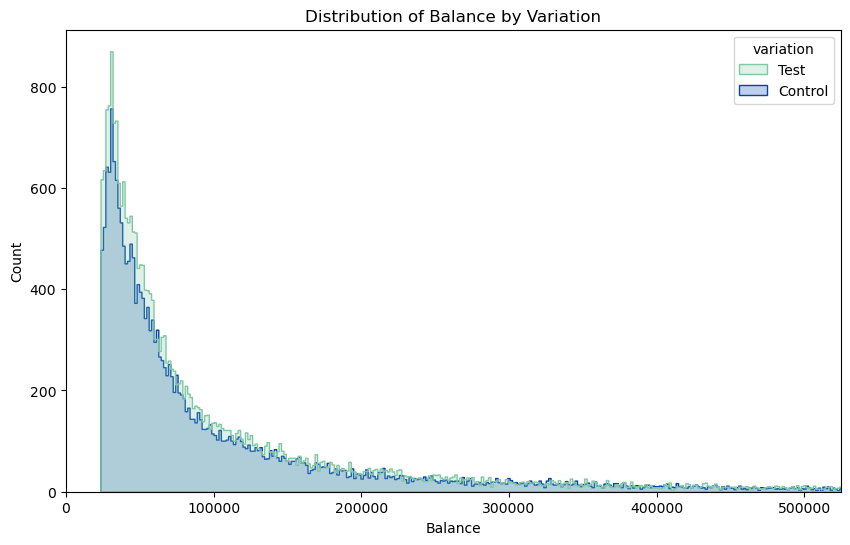

In [ ]:
custom_palette = {
    'Test': '#82c7a5',     
    'Control': '#0145ac',  
    'None': '#7f7f7f'      
}
# Plot histogram for balance
plt.figure(figsize=(10, 6))
sns.histplot(data=demographics, x='balance', hue='variation',palette=custom_palette, element='step', stat='count', common_norm=False, bins=10000)
# Custom legend handles with color
legend_handles = {
    'Test': '#82c7a5',     
    'Control': '#0145ac',  
    'None': '#7f7f7f'      
}
plt.title('Distribution of Balance by Variation')
plt.xlabel('Balance')
plt.ylabel('Count')
plt.xlim(0, demographics['balance'].quantile(0.95))  
plt.legend(handles = legend_handles, title=None)
plt.show()

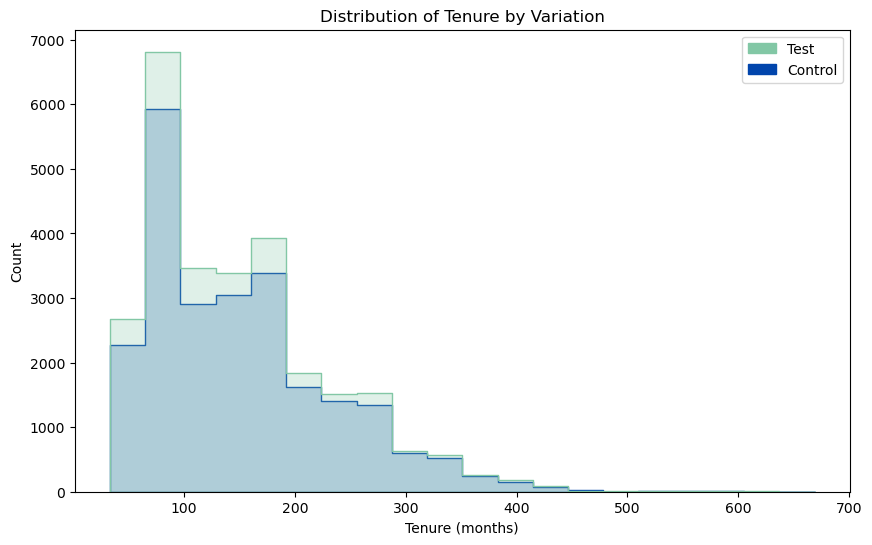

In [ ]:
custom_palette = {
    'Test': '#82c7a5',     
    'Control': '#0145ac'  
}
# Plot histogram for balance
plt.figure(figsize=(10, 6))
sns.histplot(data=demographics, x='tenure_months', hue='variation', palette=custom_palette, element='step', stat='count', bins=20)
# Custom legend handles with color
legend_handles = [
    Patch(color=color, label=label)
    for label, color in custom_palette.items()
]
plt.title('Distribution of Tenure by Variation')
plt.xlabel('Tenure (months)')
plt.ylabel('Count')
plt.legend(title=None, handles=legend_handles)
plt.show()